# Mitigation

This notebook evaluates mitigation strategies for the distribution shift between GUIDE-seq and CHANGE-seq.

A small labelled subset of CHANGE-seq training data is used for target-domain adaptation and calibration, while the existing CHANGE-seq test set remains completely untouched for final evaluation.

The target-domain subset contains 20 gRNAs and is divided into:
- 10 gRNAs for surgical fine-tuning
- 5 gRNAs for target-domain calibration
- 5 gRNAs for class-conditional conformal calibration

The mitigated models are compared against the original GUIDE-seq-trained ensemble.

## Setup

In [37]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from scipy.special import expit
from scipy.special import logit
from scipy.optimize import minimize_scalar
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
from peft import PeftModel

In [2]:
DATA_DIR = 'data/processed/'
GRNA_COL = 'target'
SEED = 2000

# Loading the fixed CHANGE-seq partitions created during preprocessing
change_train = pd.read_csv(
    DATA_DIR + 'change_train.csv',
    low_memory=False
)

change_test = pd.read_csv(
    DATA_DIR + 'change_test.csv',
    low_memory=False
)

print(
    f'CHANGE-seq train: {len(change_train):,} rows, '
    f'{change_train[GRNA_COL].nunique()} gRNAs'
)

print(
    f'CHANGE-seq test: {len(change_test):,} rows, '
    f'{change_test[GRNA_COL].nunique()} gRNAs'
)

CHANGE-seq train: 2,352,636 rows, 88 gRNAs
CHANGE-seq test: 520,991 rows, 22 gRNAs


In [3]:
# Confirms the existing CHANGE-seq train and test partitions remain disjointed
assert set(change_train[GRNA_COL]).isdisjoint(
    set(change_test[GRNA_COL])
)

print('PASS - CHANGE-seq train and test gRNAs are disjoint')

PASS - CHANGE-seq train and test gRNAs are disjoint


## Target-Domain Data Split

Twenty gRNAs are sampled from the existing CHANGE-seq training partition using a fixed random seed. These are divided into separate adaptation, calibration and conformal-calibration subsets.

The remaining CHANGE-seq training gRNAs are not used for mitigation. The original CHANGE-seq test set remains untouched.

In [4]:
# Randomly selecting 20 labelled target-domain gRNAs
rng = np.random.default_rng(SEED)

change_train_guides = np.array(
    sorted(change_train[GRNA_COL].unique())
)

selected_guides = rng.choice(
    change_train_guides,
    size=20,
    replace=False
)

# Fixed 10 / 5 / 5 split
adapt_guides = selected_guides[:10]
calib_guides = selected_guides[10:15]
conformal_guides = selected_guides[15:20]

change_adapt = (
    change_train[
        change_train[GRNA_COL].isin(adapt_guides)
    ]
    .copy()
    .reset_index(drop=True)
)

change_calib = (
    change_train[
        change_train[GRNA_COL].isin(calib_guides)
    ]
    .copy()
    .reset_index(drop=True)
)

change_conformal = (
    change_train[
        change_train[GRNA_COL].isin(conformal_guides)
    ]
    .copy()
    .reset_index(drop=True)
)

In [5]:
# Checks that each target subset contains the intended number of gRNAs
assert change_adapt[GRNA_COL].nunique() == 10
assert change_calib[GRNA_COL].nunique() == 5
assert change_conformal[GRNA_COL].nunique() == 5

# Checks there is no gRNA overlap between target subsets
assert set(adapt_guides).isdisjoint(set(calib_guides))
assert set(adapt_guides).isdisjoint(set(conformal_guides))
assert set(calib_guides).isdisjoint(set(conformal_guides))

# Checks none of the mitigation gRNAs occur in the untouched test set
test_guides = set(change_test[GRNA_COL])

assert set(adapt_guides).isdisjoint(test_guides)
assert set(calib_guides).isdisjoint(test_guides)
assert set(conformal_guides).isdisjoint(test_guides)

print('PASS - target-domain subsets are gRNA-disjoint')
print('PASS - CHANGE-seq test set remains untouched')

PASS - target-domain subsets are gRNA-disjoint
PASS - CHANGE-seq test set remains untouched


In [6]:
def describe_subset(name, df):
    n_pos = int(df['label'].sum())
    n_neg = len(df) - n_pos

    print(name)
    print(f'Rows: {len(df):,}')
    print(f'gRNAs: {df[GRNA_COL].nunique()}')
    print(f'Positives: {n_pos:,}')
    print(f'Negatives: {n_neg:,}')
    print(f'Positive rate: {df["label"].mean():.4%}')


describe_subset('Adaptation', change_adapt)
describe_subset('Calibration', change_calib)
describe_subset('Conformal calibration', change_conformal)
describe_subset('Final test', change_test)

Adaptation
Rows: 284,410
gRNAs: 10
Positives: 1,434
Negatives: 282,976
Positive rate: 0.5042%
Calibration
Rows: 113,596
gRNAs: 5
Positives: 573
Negatives: 113,023
Positive rate: 0.5044%
Conformal calibration
Rows: 187,364
gRNAs: 5
Positives: 2,811
Negatives: 184,553
Positive rate: 1.5003%
Final test
Rows: 520,991
gRNAs: 22
Positives: 6,610
Negatives: 514,381
Positive rate: 1.2687%


In [7]:
# Saves the fixed target-domain subsets for later mitigation experiments
MITIGATION_DIR = 'data/mitigation/'
os.makedirs(MITIGATION_DIR, exist_ok=True)

change_adapt.to_csv(
    MITIGATION_DIR + 'change_adapt.csv',
    index=False
)

change_calib.to_csv(
    MITIGATION_DIR + 'change_calib.csv',
    index=False
)

change_conformal.to_csv(
    MITIGATION_DIR + 'change_conformal.csv',
    index=False
)

np.save(
    MITIGATION_DIR + 'adapt_guides.npy',
    adapt_guides
)

np.save(
    MITIGATION_DIR + 'calib_guides.npy',
    calib_guides
)

np.save(
    MITIGATION_DIR + 'conformal_guides.npy',
    conformal_guides
)

print('Saved fixed mitigation subsets to', MITIGATION_DIR)

Saved fixed mitigation subsets to data/mitigation/


In [8]:
# Confirms the saved subsets reconstruct exactly the selected 20 gRNAs
selected_saved = (
    set(adapt_guides)
    | set(calib_guides)
    | set(conformal_guides)
)

assert len(selected_saved) == 20
assert selected_saved.issubset(set(change_train[GRNA_COL]))

print('PASS - fixed 10/5/5 mitigation split saved')

PASS - fixed 10/5/5 mitigation split saved


## Original GUIDE-Trained Ensemble

The five ensemble members are loaded from the saved models produced during ensemble training.

Before any target-domain adaptation is performed, the loaded models are checked against the previously saved CHANGE-seq predictions to confirm that the original ensemble has been reconstructed correctly.

In [10]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f'Using device: {device}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


In [11]:
TARGET_COL = 'offtarget_sequence'
DNABERT_MODEL = 'zhihan1996/DNA_bert_3'
K = 3

# Loads the same DNABERT tokeniser used during ensemble training
tokenizer = AutoTokenizer.from_pretrained(DNABERT_MODEL, trust_remote_code=True)

print(f'Tokeniser loaded: {DNABERT_MODEL}')

Tokeniser loaded: zhihan1996/DNA_bert_3


In [12]:
# Converts a DNA sequence into overlapping 3-mers for DNABERT input
def sequence_to_kmers(seq, k=K):
    return ' '.join(
        seq[i:i+k]
        for i in range(len(seq) - k + 1)
    )

In [13]:
# Tokenises sequences on the fly instead of storing the full encoded dataset
class CRISPRDataset(Dataset):
    def __init__(
        self,
        df,
        grna_col,
        target_col,
        tokenizer,
        max_length=45
    ):
        self.df = df.reset_index(drop=True)
        self.grna_col = grna_col
        self.target_col = target_col
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.labels = torch.tensor(
            self.df['label'].values,
            dtype=torch.float32
        )

        # Converts to lists for fast indexing
        self.grna_seqs = self.df[grna_col].tolist()
        self.target_seqs = self.df[target_col].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        grna_kmers = sequence_to_kmers(
            self.grna_seqs[idx]
        )

        target_kmers = sequence_to_kmers(
            self.target_seqs[idx]
        )

        encoded = self.tokenizer(
            grna_kmers,
            target_kmers,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids':
                encoded['input_ids'].squeeze(0),

            'attention_mask':
                encoded['attention_mask'].squeeze(0),

            'token_type_ids':
                encoded['token_type_ids'].squeeze(0),

            'label':
                self.labels[idx]
        }

In [14]:
# DNABERT encoder with a binary classification head
class DNABERTClassifier(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.backbone = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True
        )

        self.dropout = nn.Dropout(0.1)

        self.classifier = nn.Linear(
            self.backbone.config.hidden_size,
            1
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids
    ):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        cls_embedding = (
            outputs.last_hidden_state[:, 0, :]
        )

        logits = self.classifier(
            self.dropout(cls_embedding)
        )

        return logits.squeeze(-1)

In [15]:
MODEL_DIR = 'models/'
N_MEMBERS = 5

# Checks that all five saved ensemble members are available
for i in range(1, N_MEMBERS + 1):
    member_dir = os.path.join(
        MODEL_DIR,
        f'ensemble_member_{i}'
    )

    assert os.path.isdir(member_dir)
    assert os.path.isfile(
        os.path.join(member_dir, 'classifier.pt')
    )

print('PASS - all five saved ensemble members found')

PASS - all five saved ensemble members found


In [16]:
def load_ensemble(
    save_dir,
    n_members,
    model_name
):
    ensemble = []

    for i in range(1, n_members + 1):
        member_dir = os.path.join(
            save_dir,
            f'ensemble_member_{i}'
        )

        # Rebuilds model and loads saved LoRA adapter
        model = DNABERTClassifier(model_name)

        model.backbone = PeftModel.from_pretrained(
            model.backbone,
            member_dir,
            is_trainable=False
        )

        # Loads trained classifier head
        model.classifier.load_state_dict(
            torch.load(
                os.path.join(
                    member_dir,
                    'classifier.pt'
                ),
                map_location='cpu'
            )
        )

        model.eval()
        ensemble.append(model)

        print(f'Loaded member {i}')

    return ensemble

In [17]:
ensemble = load_ensemble(
    MODEL_DIR,
    N_MEMBERS,
    DNABERT_MODEL
)

assert len(ensemble) == 5

print('\nPASS - original GUIDE-trained ensemble loaded')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: zhihan1996/DNA_bert_3
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded member 1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: zhihan1996/DNA_bert_3
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[transformers] BertModel LOAD REPORT from: zhihan1996/DNA_bert_3
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded member 4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: zhihan1996/DNA_bert_3
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded member 5

PASS - original GUIDE-trained ensemble loaded


In [18]:
SANITY_N = 2000

sanity_df = (
    change_test
    .iloc[:SANITY_N]
    .copy()
    .reset_index(drop=True)
)

sanity_dataset = CRISPRDataset(
    sanity_df,
    GRNA_COL,
    TARGET_COL,
    tokenizer
)

In [19]:
# Returns raw logits for each ensemble member
def ensemble_predict_logits(
    ensemble,
    dataset,
    batch_size=512
):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    all_logits = []

    for i, model in enumerate(ensemble, 1):
        model.to(device)
        model.eval()

        member_logits = []

        with torch.inference_mode():
            for batch in loader:
                logits = model(
                    batch['input_ids'].to(device),
                    batch['attention_mask'].to(device),
                    batch['token_type_ids'].to(device)
                )

                member_logits.append(
                    logits.float().cpu().numpy()
                )

        all_logits.append(
            np.concatenate(member_logits)
        )

        model.to('cpu')

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(
            f'Member {i}/{len(ensemble)} done'
        )

    return np.stack(all_logits)

In [20]:
sanity_logits = ensemble_predict_logits(
    ensemble,
    sanity_dataset
)

saved_change_logits = np.load(
    DATA_DIR + 'change_member_logits.npy'
)

expected_logits = (
    saved_change_logits[:, :SANITY_N]
)

print(f'Generated shape: {sanity_logits.shape}')
print(f'Saved shape: {expected_logits.shape}')

max_difference = np.max(
    np.abs(sanity_logits - expected_logits)
)

print(
    f'Maximum absolute difference: '
    f'{max_difference:.8f}'
)

Member 1/5 done
Member 2/5 done
Member 3/5 done
Member 4/5 done
Member 5/5 done
Generated shape: (5, 2000)
Saved shape: (5, 2000)
Maximum absolute difference: 0.00067186


In [22]:
absolute_difference = np.abs(
    sanity_logits - expected_logits
)

print(
    f'Mean absolute difference: '
    f'{absolute_difference.mean():.8f}'
)

print(
    f'99th percentile difference: '
    f'{np.quantile(absolute_difference, 0.99):.8f}'
)

print(
    f'Maximum absolute difference: '
    f'{absolute_difference.max():.8f}'
)

assert absolute_difference.max() < 1e-3

print(
    'PASS - loaded ensemble reproduces '
    'the saved CHANGE-seq predictions'
)

Mean absolute difference: 0.00000071
99th percentile difference: 0.00000620
Maximum absolute difference: 0.00067186
PASS - loaded ensemble reproduces the saved CHANGE-seq predictions


## Target-Domain Temperature Scaling

Temperature scaling is evaluated as a calibration-only mitigation strategy.

The original GUIDE-seq-trained ensemble is not fine-tuned. Instead, a single temperature parameter is fitted using the five-gRNA CHANGE-seq calibration subset. The existing sampling-prior correction is applied before calibration.

The fitted temperature is then evaluated on the untouched CHANGE-seq test set.

In [24]:
# Creates the target-domain calibration dataset
change_calib_dataset = CRISPRDataset(
    change_calib,
    GRNA_COL,
    TARGET_COL,
    tokenizer
)

print(f'Calibration samples: {len(change_calib_dataset):,}')

Calibration samples: 113,596


In [25]:
# Generates GUIDE-trained ensemble logits on the target calibration subset
calib_member_logits = ensemble_predict_logits(
    ensemble,
    change_calib_dataset
)

assert calib_member_logits.shape == (
    N_MEMBERS,
    len(change_calib)
)

print(f'Calibration logits: {calib_member_logits.shape}')

Member 1/5 done
Member 2/5 done
Member 3/5 done
Member 4/5 done
Member 5/5 done
Calibration logits: (5, 113596)


In [26]:
# Loads the negative-sampling correction used by the original ensemble
metadata = np.load(
    DATA_DIR + 'ensemble_training_metadata.npz'
)

OFFSET = float(
    metadata['sampling_logit_offset']
)

print(f'Logit correction offset: {OFFSET:.6f}')

Logit correction offset: -4.494835


In [27]:
y_calib = change_calib['label'].to_numpy()

# Applies the original training-prior correction to each ensemble member
calib_member_probs = expit(
    calib_member_logits + OFFSET
)

# Original ensemble probability
calib_mean_probs = calib_member_probs.mean(axis=0)

print(f'Calibration prevalence: {y_calib.mean():.6f}')
print(
    f'Original mean prediction: '
    f'{calib_mean_probs.mean():.6f}'
)

Calibration prevalence: 0.005044
Original mean prediction: 0.000448


In [28]:
# Converts the original ensemble probabilities to logits
# Clipping prevents numerical problems at probabilities exactly 0 or 1
EPS = 1e-12

calib_mean_probs_clipped = np.clip(
    calib_mean_probs,
    EPS,
    1 - EPS
)

calib_ensemble_logits = logit(
    calib_mean_probs_clipped
)

assert np.isfinite(calib_ensemble_logits).all()

print(
    f'Ensemble logit range: '
    f'{calib_ensemble_logits.min():.3f} to '
    f'{calib_ensemble_logits.max():.3f}'
)

Ensemble logit range: -9.427 to -4.924


In [29]:
# Binary negative log-likelihood after temperature scaling
def temperature_nll(log_temperature, logits, labels):
    temperature = np.exp(log_temperature)
    scaled_logits = logits / temperature

    return np.mean(
        np.logaddexp(0.0, scaled_logits)
        - labels * scaled_logits
    )

In [30]:
# Fits a single positive temperature on CHANGE-seq calibration data
temperature_result = minimize_scalar(
    temperature_nll,
    args=(calib_ensemble_logits, y_calib),
    method='bounded',
    bounds=(-5, 5)
)

TEMPERATURE = np.exp(
    temperature_result.x
)

assert temperature_result.success
assert TEMPERATURE > 0

print(f'Fitted temperature: {TEMPERATURE:.6f}')
print(
    f'Calibration NLL: '
    f'{temperature_result.fun:.6f}'
)

Fitted temperature: 1.465946
Calibration NLL: 0.030184


In [31]:
# Applies the fitted temperature to the calibration subset
calib_temp_probs = expit(
    calib_ensemble_logits / TEMPERATURE
)

print(
    f'Original mean prediction: '
    f'{calib_mean_probs.mean():.6f}'
)

print(
    f'Temperature-scaled mean prediction: '
    f'{calib_temp_probs.mean():.6f}'
)

print(
    f'Observed prevalence: '
    f'{y_calib.mean():.6f}'
)

Original mean prediction: 0.000448
Temperature-scaled mean prediction: 0.004866
Observed prevalence: 0.005044


In [32]:
# Expected Calibration Error using either quantile or uniform-width bins
def ece(y, p, n_bins=10, strategy='quantile'):
    if strategy == 'quantile':
        edges = np.unique(
            np.quantile(
                p,
                np.linspace(0, 1, n_bins + 1)
            )
        )
    else:
        edges = np.linspace(
            0,
            1,
            n_bins + 1
        )

    idx = np.clip(
        np.digitize(
            p,
            edges[1:-1],
            right=False
        ),
        0,
        len(edges) - 2
    )

    total = 0.0

    for b in range(len(edges) - 1):
        mask = idx == b

        if not mask.any():
            continue

        total += (
            mask.mean()
            * abs(
                p[mask].mean()
                - y[mask].mean()
            )
        )

    return total

In [33]:
# Compares calibration before and after target-domain temperature scaling
original_nll = temperature_nll(
    0.0,
    calib_ensemble_logits,
    y_calib
)

scaled_nll = temperature_nll(
    np.log(TEMPERATURE),
    calib_ensemble_logits,
    y_calib
)

print('CHANGE-seq calibration subset')

print('\nOriginal ensemble:')
print(f'NLL: {original_nll:.6f}')
print(
    f'ECE: '
    f'{ece(y_calib, calib_mean_probs):.6f}'
)
print(
    f'Brier: '
    f'{brier_score_loss(y_calib, calib_mean_probs):.6f}'
)

print('\nTemperature scaled:')
print(f'NLL: {scaled_nll:.6f}')
print(
    f'ECE: '
    f'{ece(y_calib, calib_temp_probs):.6f}'
)
print(
    f'Brier: '
    f'{brier_score_loss(y_calib, calib_temp_probs):.6f}'
)

CHANGE-seq calibration subset

Original ensemble:
NLL: 0.037540
ECE: 0.004596
Brier: 0.005035

Temperature scaled:
NLL: 0.030184
ECE: 0.001393
Brier: 0.004996


### Evaluation on the Untouched CHANGE-seq Test Set

The temperature fitted using the five target-domain calibration gRNAs is now applied without modification to the original held-out CHANGE-seq test set.

Because temperature scaling is a monotonic transformation of the ensemble score, ranking performance should remain unchanged. The main comparison therefore focuses on probability calibration.

In [34]:
# Labels for the untouched CHANGE-seq test set
y_change_test = change_test['label'].to_numpy()

# Applies the original sampling-prior correction to each ensemble member
test_member_probs = expit(
    saved_change_logits + OFFSET
)

# Original GUIDE-trained ensemble probability
test_mean_probs = test_member_probs.mean(axis=0)

assert len(test_mean_probs) == len(y_change_test)
assert np.isfinite(test_mean_probs).all()

print(f'Test samples: {len(y_change_test):,}')
print(f'Test prevalence: {y_change_test.mean():.6f}')
print(f'Original mean prediction: {test_mean_probs.mean():.6f}')

Test samples: 520,991
Test prevalence: 0.012687
Original mean prediction: 0.000419


In [35]:
# Converts original ensemble probabilities to logits
test_mean_probs_clipped = np.clip(
    test_mean_probs,
    EPS,
    1 - EPS
)

test_ensemble_logits = logit(
    test_mean_probs_clipped
)

# Applies the fixed target-domain temperature
test_temp_probs = expit(
    test_ensemble_logits / TEMPERATURE
)

assert np.isfinite(test_temp_probs).all()

print(f'Fitted temperature: {TEMPERATURE:.6f}')
print(
    f'Temperature-scaled mean prediction: '
    f'{test_temp_probs.mean():.6f}'
)
print(
    f'Observed prevalence: '
    f'{y_change_test.mean():.6f}'
)

Fitted temperature: 1.465946
Temperature-scaled mean prediction: 0.004578
Observed prevalence: 0.012687


In [36]:
# Compares the original and temperature-scaled ensemble on the completely untouched CHANGE-seq test set
original_test_nll = temperature_nll(
    0.0,
    test_ensemble_logits,
    y_change_test
)

scaled_test_nll = temperature_nll(
    np.log(TEMPERATURE),
    test_ensemble_logits,
    y_change_test
)

print('CHANGE-seq test set')

print('\nOriginal ensemble:')
print(
    f'AUROC: '
    f'{roc_auc_score(y_change_test, test_mean_probs):.4f}'
)
print(
    f'AUPRC: '
    f'{average_precision_score(y_change_test, test_mean_probs):.4f}'
)
print(f'NLL: {original_test_nll:.6f}')
print(
    f'ECE: '
    f'{ece(y_change_test, test_mean_probs):.6f}'
)
print(
    f'Brier: '
    f'{brier_score_loss(y_change_test, test_mean_probs):.6f}'
)

print('\nTemperature scaled:')
print(
    f'AUROC: '
    f'{roc_auc_score(y_change_test, test_temp_probs):.4f}'
)
print(
    f'AUPRC: '
    f'{average_precision_score(y_change_test, test_temp_probs):.4f}'
)
print(f'NLL: {scaled_test_nll:.6f}')
print(
    f'ECE: '
    f'{ece(y_change_test, test_temp_probs):.6f}'
)
print(
    f'Brier: '
    f'{brier_score_loss(y_change_test, test_temp_probs):.6f}'
)

CHANGE-seq test set

Original ensemble:
AUROC: 0.8588
AUPRC: 0.1015
NLL: 0.088699
ECE: 0.012268
Brier: 0.012656

Temperature scaled:
AUROC: 0.8588
AUPRC: 0.1015
NLL: 0.064813
ECE: 0.009493
Brier: 0.012470


In [38]:
# Calculates reliability statistics using quantile bins
def reliability_stats(y_true, y_prob, n_bins=10):
    edges = np.quantile(
        y_prob,
        np.linspace(0, 1, n_bins + 1)
    )
    edges = np.unique(edges)

    rows = []

    for i in range(len(edges) - 1):
        if i == len(edges) - 2:
            mask = (
                (y_prob >= edges[i])
                & (y_prob <= edges[i + 1])
            )
        else:
            mask = (
                (y_prob >= edges[i])
                & (y_prob < edges[i + 1])
            )

        if not mask.any():
            continue

        rows.append({
            'mean_pred': y_prob[mask].mean(),
            'observed': y_true[mask].mean(),
            'n': mask.sum()
        })

    return pd.DataFrame(rows)

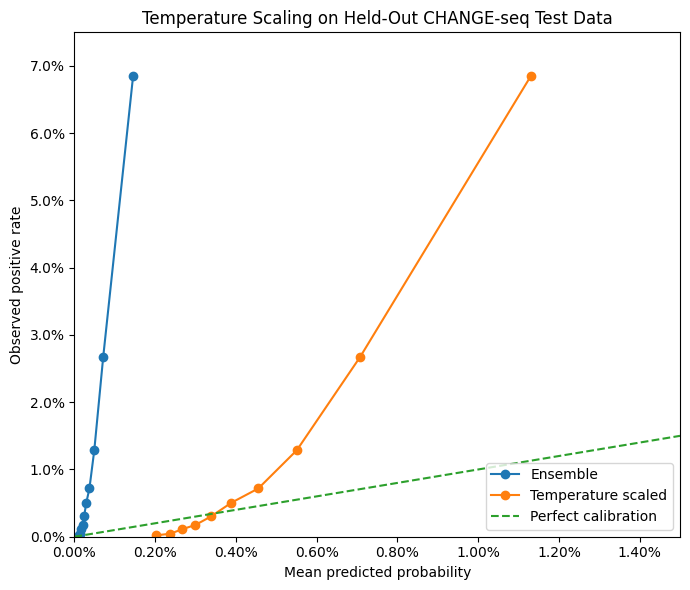

In [46]:
# Reliability diagram before and after target-domain temperature scaling
from matplotlib.ticker import PercentFormatter

original_stats = reliability_stats(
    y_change_test,
    test_mean_probs
)

scaled_stats = reliability_stats(
    y_change_test,
    test_temp_probs
)

plt.figure(figsize=(7, 6))

plt.plot(
    original_stats['mean_pred'],
    original_stats['observed'],
    marker='o',
    label='Ensemble'
)

plt.plot(
    scaled_stats['mean_pred'],
    scaled_stats['observed'],
    marker='o',
    label='Temperature scaled'
)

# Reduced x-axis range for clearer visualisation
x_limit = 0.015
y_limit = 0.075

plt.plot(
    [0, x_limit],
    [0, x_limit],
    linestyle='--',
    label='Perfect calibration'
)

plt.xlim(0, x_limit)
plt.ylim(0, y_limit)

plt.xlabel('Mean predicted probability')
plt.ylabel('Observed positive rate')
plt.title(
    'Temperature Scaling on Held-Out CHANGE-seq Test Data'
)

# Display probabilities as percentages
ax = plt.gca()
ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)
ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.legend(loc='lower right', frameon=True)
plt.tight_layout()

RESULTS_DIR = 'results/mitigation/'
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.savefig(
    RESULTS_DIR + 'temperature_scaling_reliability.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()